### Thông tin về Bộ dữ liệu
### Bối cảnh

Phân tích Đặc điểm Khách hàng (Customer Personality Analysis) là quá trình nghiên cứu toàn diện về các đối tượng khách hàng lý tưởng của một doanh nghiệp. Phân tích này hỗ trợ doanh nghiệp hiểu rõ hơn về tệp khách hàng của mình, từ đó tạo điều kiện cho việc tùy chỉnh sản phẩm dựa trên nhu cầu, hành vi và các mối quan tâm cụ thể của từng nhóm khách hàng khác nhau.

Thông qua việc thực hiện phân tích đặc điểm khách hàng, doanh nghiệp có thể tinh chỉnh sản phẩm để hướng tới các nhóm khách hàng mục tiêu từ nhiều phân khúc đa dạng. Ví dụ, thay vì tiếp thị một sản phẩm mới cho mọi khách hàng trong cơ sở dữ liệu, công ty có thể xác định phân khúc khách hàng có khả năng mua hàng cao nhất để tập trung các nỗ lực marketing vào đúng nhóm đối tượng đó.

### Các Thuộc tính

### Thông tin cá nhân (People)

ID: Mã định danh duy nhất của khách hàng.

Year_Birth: Năm sinh của khách hàng.

Education: Trình độ học vấn.

Marital_Status: Tình trạng hôn nhân.

Income: Thu nhập hộ gia đình hàng năm.

Kidhome: Số lượng trẻ nhỏ trong hộ gia đình.

Teenhome: Số lượng trẻ vị thành niên trong hộ gia đình.

Dt_Customer: Ngày khách hàng đăng ký hệ thống của công ty.

Recency: Số ngày kể từ lần mua hàng cuối cùng.

Complain: Nhận giá trị 1 nếu khách hàng có khiếu nại trong 2 năm qua, ngược lại nhận giá trị 0.

### Sản phẩm (Products)

MntWines: Số tiền chi cho các mặt hàng rượu trong 2 năm qua.

MntFruits: Số tiền chi cho các mặt hàng hoa quả trong 2 năm qua.

MntMeatProducts: Số tiền chi cho các mặt hàng thịt trong 2 năm qua.

MntFishProducts: Số tiền chi cho các mặt hàng cá trong 2 năm qua.

MntSweetProducts: Số tiền chi cho các mặt hàng bánh kẹo trong 2 năm qua.

MntGoldProds: Số tiền chi cho các mặt hàng vàng/trang sức trong 2 năm qua.

### Thúc đẩy thương mại (Promotion)

NumDealsPurchases: Số lượng giao dịch được thực hiện có sử dụng mã giảm giá.

AcceptedCmp1: Nhận giá trị 1 nếu khách hàng chấp nhận ưu đãi trong chiến dịch thứ 1, ngược lại nhận giá trị 0.

AcceptedCmp2: Nhận giá trị 1 nếu khách hàng chấp nhận ưu đãi trong chiến dịch thứ 2, ngược lại nhận giá trị 0.

AcceptedCmp3: Nhận giá trị 1 nếu khách hàng chấp nhận ưu đãi trong chiến dịch thứ 3, ngược lại nhận giá trị 0.

AcceptedCmp4: Nhận giá trị 1 nếu khách hàng chấp nhận ưu đãi trong chiến dịch thứ 4, ngược lại nhận giá trị 0.

AcceptedCmp5: Nhận giá trị 1 nếu khách hàng chấp nhận ưu đãi trong chiến dịch thứ 5, ngược lại nhận giá trị 0.

Response: Nhận giá trị 1 nếu khách hàng chấp nhận ưu đãi trong chiến dịch gần nhất, ngược lại nhận giá trị 0.

### Kênh phân phối (Place)

NumWebPurchases: Số lượng giao dịch thực hiện thông qua website của công ty.

NumCatalogPurchases: Số lượng giao dịch thực hiện qua danh mục hàng hóa (catalogue).

NumStorePurchases: Số lượng giao dịch thực hiện trực tiếp tại cửa hàng.

NumWebVisitsMonth: Số lượt truy cập vào website công ty trong tháng vừa qua.

### Mục tiêu (Target)

Sử dụng phương pháp Phân cụm (Clustering) để khái quát hóa các phân khúc khách hàng.

### 1. Import Libraries

In [3]:
from codecs import ignore_errors

pip install fg-data-profiling

Note: you may need to restart the kernel to use updated packages.


In [67]:
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
%matplotlib inline
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

from ydata_profiling import ProfileReport

### 2. Import Data

In [5]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 50)

In [6]:
df = pd.read_csv("marketing_campaign.csv", sep=";")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

### 3. Data Cleaning

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Dataframe hiện chứa một số lỗi cần được xử lý trước khi tiến hành các bước sau 

Có 24 giá trị bị thiếu trong cột "Income"
Cột "Dt_Customer" đang ở kiểu dữ liệu "Object" với định dạng "yyyy-mm-dd", thay vì kiểu datetime64

In [10]:
# Drop những cột chứa giá trị NaN
df = df.dropna()

In [11]:
# Convert Dt_customer to Datetime64
df.loc[:, 'Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%Y-%m-%d')

print('Min date in the dataset:', min(df['Dt_Customer']))
print('Max date in the dataset:', max(df['Dt_Customer']))

Min date in the dataset: 2012-07-30 00:00:00
Max date in the dataset: 2014-06-29 00:00:00


In [17]:
profile = ProfileReport(df, title="Marketing Campaign Report", explorative=True)

# Hiển thị trực tiếp trong Jupyter Notebook
profile.to_file("Marketing Campaign Report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 25.40it/s]


### 4. Feature Engineering

In [18]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

Tạo ra các feature mới từ các features có sẵn

Total_Spent = Sum of ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
Living_Situation = alone / not_alone
Education_Level = undergraduate / graduate / postgraduate
Total_Children = Sum of ['Kidhome', 'Teenhome']
Is_Parent = IF Total_Children > 0, Yes (1) ELSE No (0)
Age = 2026 - Year_Birth

In [20]:
# Ft. 1: Total_Spent
df['Total_Spent'] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + \
             df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

# Ft. 2: Living_Situation
df.loc[df['Marital_Status'].isin(['Together','Married']),'Living_Situation'] = 'alone'
df.loc[df['Marital_Status'].isin(['Single','Divorced','Widow','Alone','Absurd','YOLO']),'Living_Situation'] = 'not_alone'

# Ft. 3: Education_Level
df.loc[df['Education'].isin(['Graduation']),'Education_Level'] = 'undergraduate'
df.loc[df['Education'].isin(['Basic','2n Cycle']),'Education_Level'] = 'graduate'
df.loc[df['Education'].isin(['PhD','Master']),'Education_Level'] = 'postgraduate'

# Ft. 4: Total_Children
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Ft. 5: Is_Parent
df.loc[df['Total_Children'] > 0, 'Is_Parent'] = 1 #Yes
df.loc[df['Total_Children'] == 0, 'Is_Parent'] = 0 #No

# Ft. 6: Age
df['Age'] = 2026 - df['Year_Birth']

In [22]:
df.columns

Index(['Education', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Total_Spent',
       'Living_Situation', 'Education_Level', 'Total_Children', 'Is_Parent',
       'Age'],
      dtype='object')

Xóa một số cột

In [43]:
drop_cols = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
df =  df.drop(drop_cols, axis = 1, errors='ignore')

In [44]:
df.columns

Index(['Education', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'Total_Spent', 'Living_Situation',
       'Education_Level', 'Total_Children', 'Is_Parent', 'Age', 'Income_log'],
      dtype='object')

In [24]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Total_Spent,Total_Children,Is_Parent,Age
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,2.323556,4.085289,2.671029,5.800993,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,0.150271,607.075361,0.947202,0.714350,57.179603
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,1.923716,2.740951,2.926734,3.250785,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.357417,602.900476,0.749062,0.451825,11.985554
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,30.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.000000,0.000000,0.000000,49.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,396.500000,1.000000,1.000000,56.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1048.000000,1.000000,1.000000,67.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2525.000000,3.000000,1.000000,133.000000


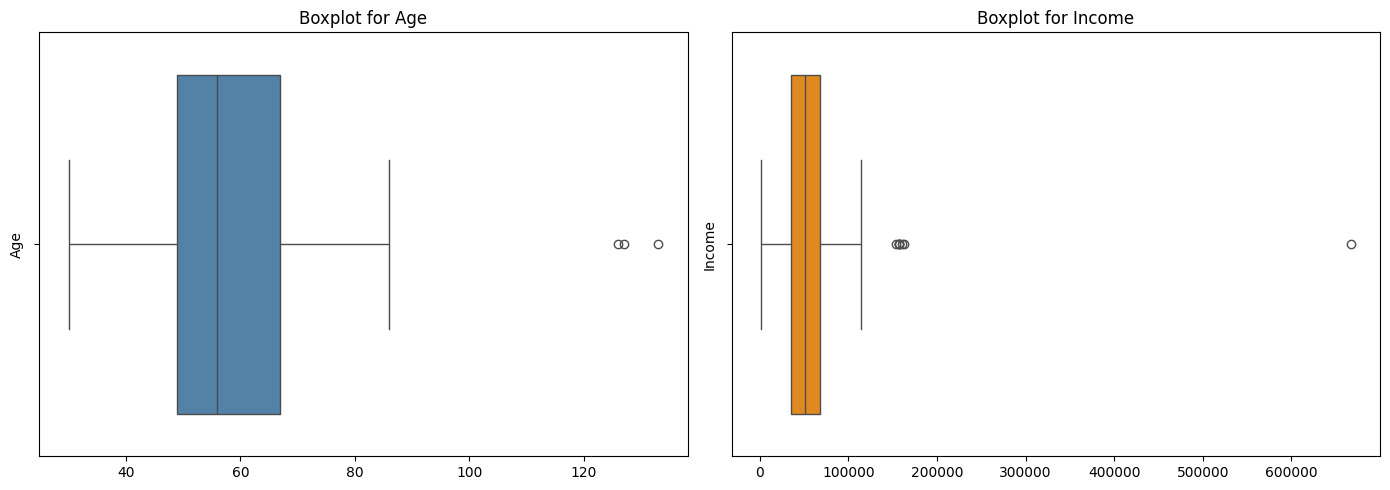

In [31]:
fig, axes = plt.subplots(ncols=2,nrows=1,figsize = (14,5))

# Boxplot for Age
sns.boxplot(data=df, x='Age', ax=axes[0], color = 'steelblue')
axes[0].set_title('Boxplot for Age')
axes[0].set_ylabel('Age')
axes[0].set_xlabel('')

# Boxplot for 'Income'
sns.boxplot(data=df, x='Income', ax=axes[1], color = 'darkorange')
axes[1].set_title('Boxplot for Income')
axes[1].set_ylabel('Income')
axes[1].set_xlabel('')

# Adjust layout to prevent overlap
plt.tight_layout()


Nhận thấy rõ, dữ liệu 2 cột này có outlier rõ rệt, ta sẽ dùng phương pháp chặt trên, chặt dưới cho cột Age và dùng Log Transformation cho cột Income

In [32]:
import pandas as pd
import numpy as np

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df['Age'] = np.where(df['Age'] < lower_limit, lower_limit,
            np.where(df['Age'] > upper_limit, upper_limit, df['Age']))

# 3. Xử lý Outlier cho 'Income' bằng phương pháp Log Transformation
df['Income_log'] = np.log1p(df['Income'])




    Age   Income  Income_log
0  69.0  58138.0   10.970592
1  72.0  46344.0   10.743869
2  61.0  71613.0   11.179046
3  42.0  26646.0   10.190432
4  45.0  58293.0   10.973254


Text(0.5, 1.0, 'Correlation Heatmap')

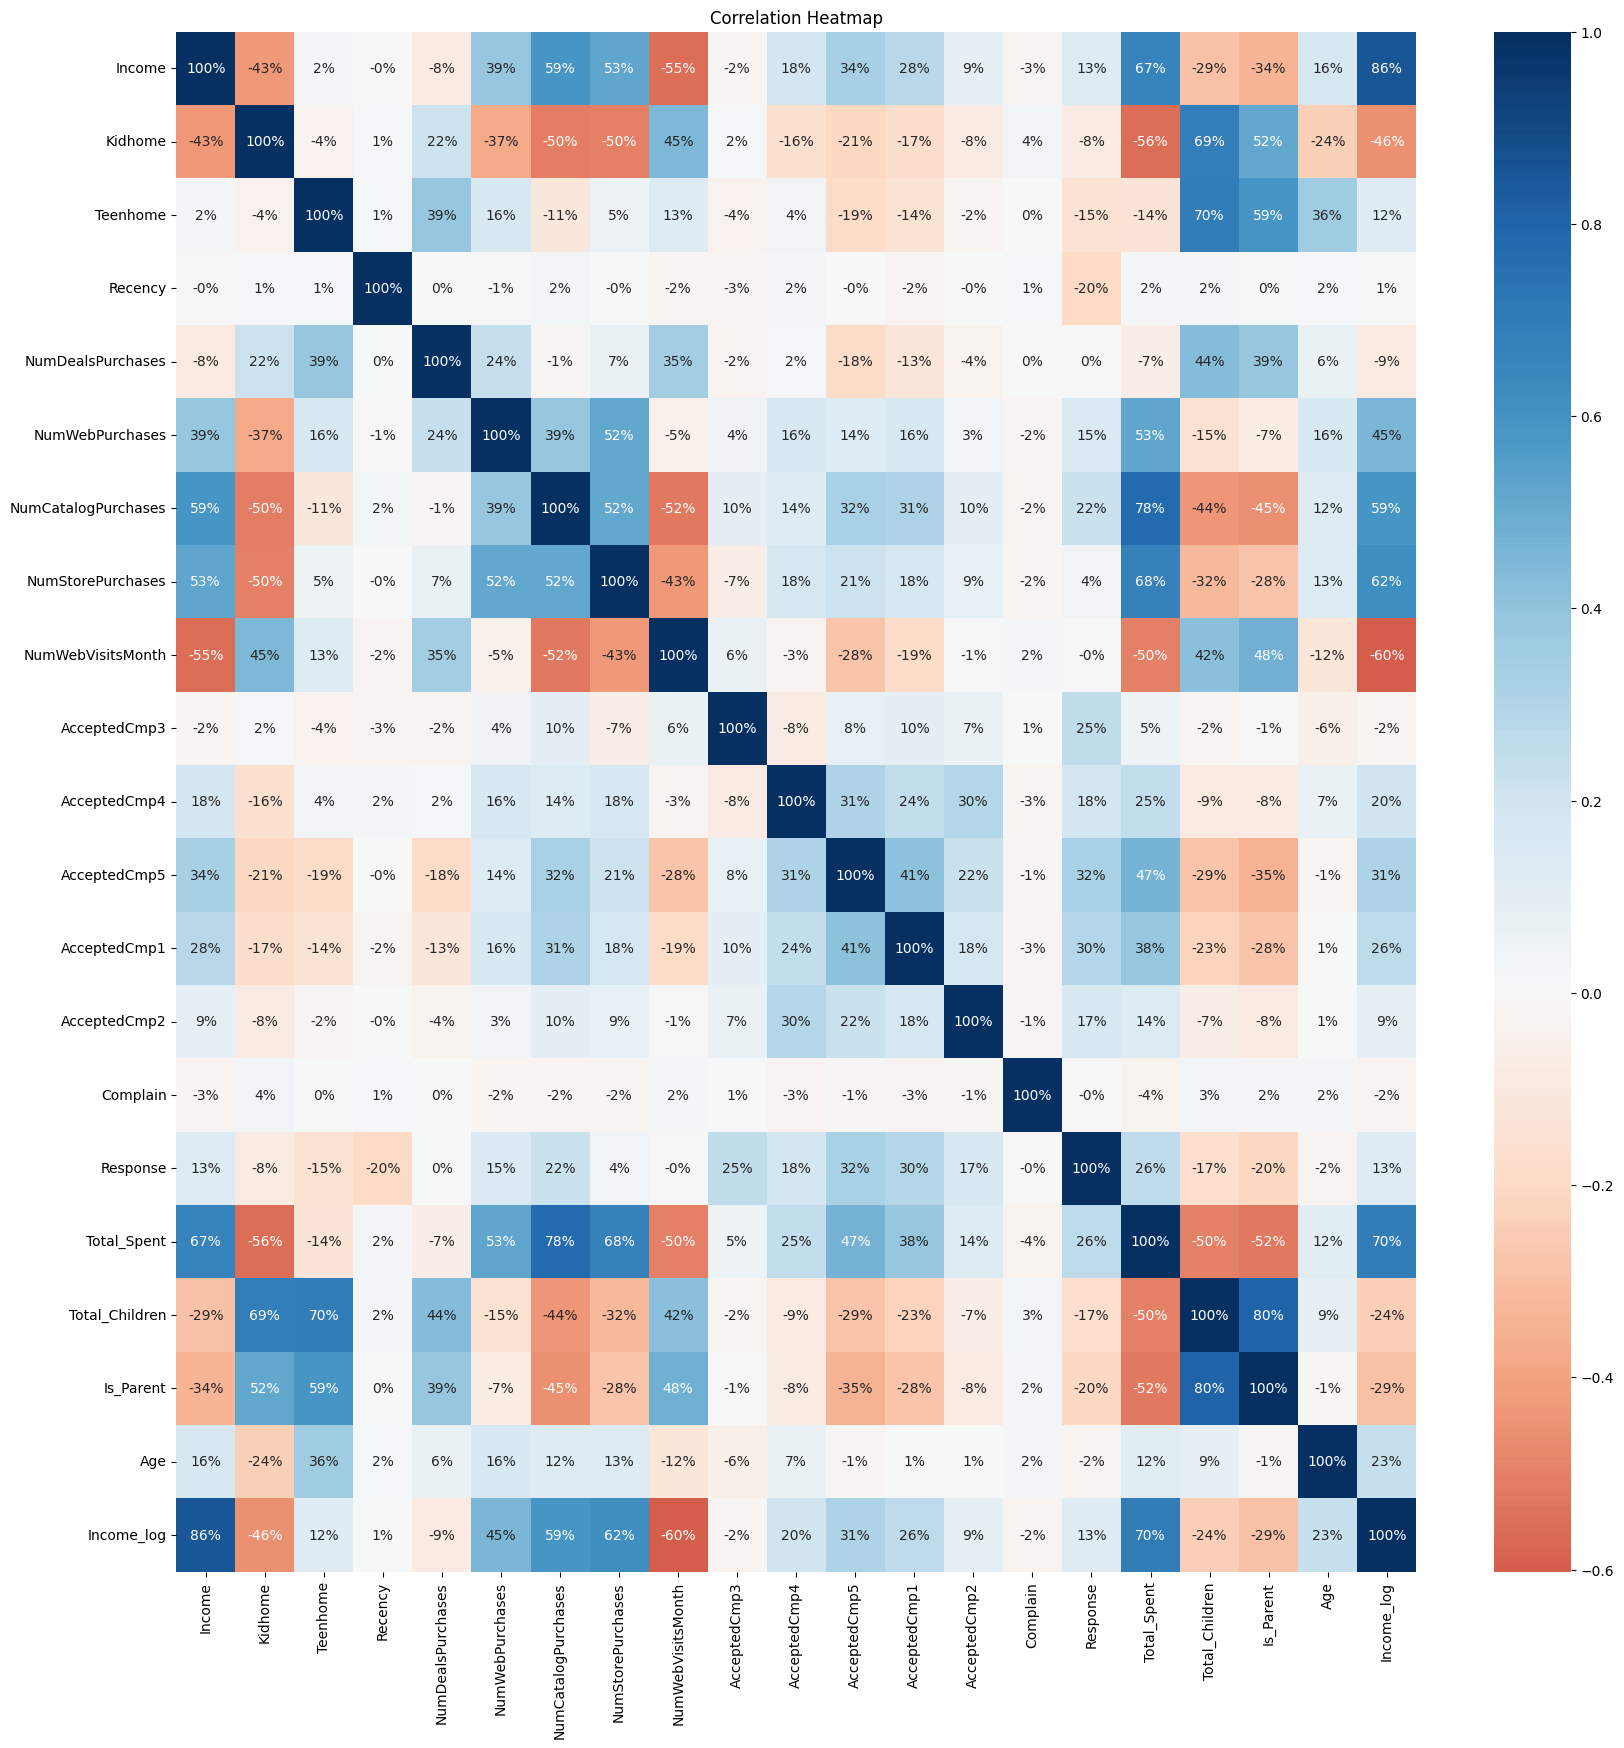

In [45]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix
            , annot=True
            , cmap= 'RdBu'
            , center=0
            , fmt = '.0%')
plt.title('Correlation Heatmap')

### PreProcessing Data

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2216 non-null   object 
 1   Income               2216 non-null   float64
 2   Kidhome              2216 non-null   int64  
 3   Teenhome             2216 non-null   int64  
 4   Recency              2216 non-null   int64  
 5   NumDealsPurchases    2216 non-null   int64  
 6   NumWebPurchases      2216 non-null   int64  
 7   NumCatalogPurchases  2216 non-null   int64  
 8   NumStorePurchases    2216 non-null   int64  
 9   NumWebVisitsMonth    2216 non-null   int64  
 10  AcceptedCmp3         2216 non-null   int64  
 11  AcceptedCmp4         2216 non-null   int64  
 12  AcceptedCmp5         2216 non-null   int64  
 13  AcceptedCmp1         2216 non-null   int64  
 14  AcceptedCmp2         2216 non-null   int64  
 15  Complain             2216 non-null   int64 

In [54]:
df.head()

,Education,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Total_Spent,Living_Situation,Education_Level,Total_Children,Is_Parent,Age,Income_log
0,Graduation,58138.0,0,0,58,3,8,10,4,7,0,0,0,0,0,0,1,1617,not_alone,undergraduate,0,0.0,69.0,10.970592
1,Graduation,46344.0,1,1,38,2,1,1,2,5,0,0,0,0,0,0,0,27,not_alone,undergraduate,2,1.0,72.0,10.743869
2,Graduation,71613.0,0,0,26,1,8,2,10,4,0,0,0,0,0,0,0,776,alone,undergraduate,0,0.0,61.0,11.179046
3,Graduation,26646.0,1,0,26,2,2,0,4,6,0,0,0,0,0,0,0,53,alone,undergraduate,1,1.0,42.0,10.190432
4,PhD,58293.0,1,0,94,5,5,3,6,5,0,0,0,0,0,0,0,422,alone,postgraduate,1,1.0,45.0,10.973254


In [56]:
# 1. Tách danh sách các cột numerical (int64 và float64)
# Chúng ta loại trừ các cột 'object' tự động
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# 2. Khởi tạo StandardScaler
scaler = StandardScaler()

# 3. Tạo một bản sao của dataframe để giữ lại dữ liệu gốc (tùy chọn)
df_scaled = df.copy()

# 4. Thực hiện fit và transform cho các cột numerical
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Kiểm tra kết quả
print("Các cột đã được scale:", numerical_cols.tolist())
print(df_scaled.head())

Các cột đã được scale: ['Income', 'Kidhome', 'Teenhome', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Total_Spent', 'Total_Children', 'Is_Parent', 'Age', 'Income_log']
    Education    Income   Kidhome  Teenhome   Recency  NumDealsPurchases  \
0  Graduation  0.234063 -0.823039 -0.928972  0.310532           0.351713   
1  Graduation -0.234559  1.039938  0.909066 -0.380509          -0.168231   
2  Graduation  0.769478 -0.823039 -0.928972 -0.795134          -0.688176   
3  Graduation -1.017239  1.039938 -0.928972 -0.795134          -0.168231   
4         PhD  0.240221  1.039938 -0.928972  1.554407           1.391603   

   NumWebPurchases  NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  \
0         1.428553             2.504712          -0.554143           0.693232   
1        -1.125881            -0.5710

In [57]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2216 non-null   object 
 1   Income               2216 non-null   float64
 2   Kidhome              2216 non-null   float64
 3   Teenhome             2216 non-null   float64
 4   Recency              2216 non-null   float64
 5   NumDealsPurchases    2216 non-null   float64
 6   NumWebPurchases      2216 non-null   float64
 7   NumCatalogPurchases  2216 non-null   float64
 8   NumStorePurchases    2216 non-null   float64
 9   NumWebVisitsMonth    2216 non-null   float64
 10  AcceptedCmp3         2216 non-null   float64
 11  AcceptedCmp4         2216 non-null   float64
 12  AcceptedCmp5         2216 non-null   float64
 13  AcceptedCmp1         2216 non-null   float64
 14  AcceptedCmp2         2216 non-null   float64
 15  Complain             2216 non-null   float6

In [58]:
df_scaled["Education"].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [59]:
education_mapping = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
}

df_scaled['Education'] = df_scaled['Education'].map(education_mapping)

print(df_scaled['Education'].unique())
display(df_scaled[['Education']].head())

[2 4 3 0 1]


,Education
0,2
1,2
2,2
3,2
4,4


In [60]:
df_scaled["Living_Situation"].unique()

array(['not_alone', 'alone'], dtype=object)

In [61]:
education_mapping = {
    "alone" : 0,
    "not_alone" : 1,
}

df_scaled['Living_Situation'] = df_scaled['Living_Situation'].map(education_mapping)

print(df_scaled['Living_Situation'].unique())
display(df_scaled[['Living_Situation']].head())

[1 0]


,Living_Situation
0,1
1,1
2,0
3,0
4,0


In [63]:
edu_level_mapping = {
    'undergraduate': 0,
    'graduate': 1,
    'postgraduate': 2
}

df_scaled['Education_Level'] = df_scaled['Education_Level'].map(edu_level_mapping)

print("Thứ tự đã mã hóa:", edu_level_mapping)
display(df_scaled[['Education_Level']].head())

Thứ tự đã mã hóa: {'undergraduate': 0, 'graduate': 1, 'postgraduate': 2}


,Education_Level
0,0
1,0
2,0
3,0
4,2


In [65]:
df_scaled.head()

,Education,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Total_Spent,Living_Situation,Education_Level,Total_Children,Is_Parent,Age,Income_log
0,2,0.234063,-0.823039,-0.928972,0.310532,0.351713,1.428553,2.504712,-0.554143,0.693232,-0.281773,-0.282705,-0.280839,-0.261661,-0.117148,-0.097812,2.377952,1.675488,1,0,-1.264803,-1.581389,1.008423,0.428623
1,2,-0.234559,1.039938,0.909066,-0.380509,-0.168231,-1.125881,-0.571082,-1.169518,-0.131574,-0.281773,-0.282705,-0.280839,-0.261661,-0.117148,-0.097812,-0.420530,-0.962358,1,0,1.405806,0.632356,1.263348,-0.019686
2,2,0.769478,-0.823039,-0.928972,-0.795134,-0.688176,1.428553,-0.229327,1.291982,-0.543978,-0.281773,-0.282705,-0.280839,-0.261661,-0.117148,-0.097812,-0.420530,0.280250,0,0,-1.264803,-1.581389,0.328625,0.840808
3,2,-1.017239,1.039938,-0.928972,-0.795134,-0.168231,-0.760962,-0.912837,-0.554143,0.280829,-0.281773,-0.282705,-0.280839,-0.261661,-0.117148,-0.097812,-0.420530,-0.919224,0,0,0.070501,0.632356,-1.285895,-1.114019
4,4,0.240221,1.039938,-0.928972,1.554407,1.391603,0.333796,0.112428,0.061232,-0.131574,-0.281773,-0.282705,-0.280839,-0.261661,-0.117148,-0.097812,-0.420530,-0.307044,0,2,0.070501,0.632356,-1.030971,0.433888


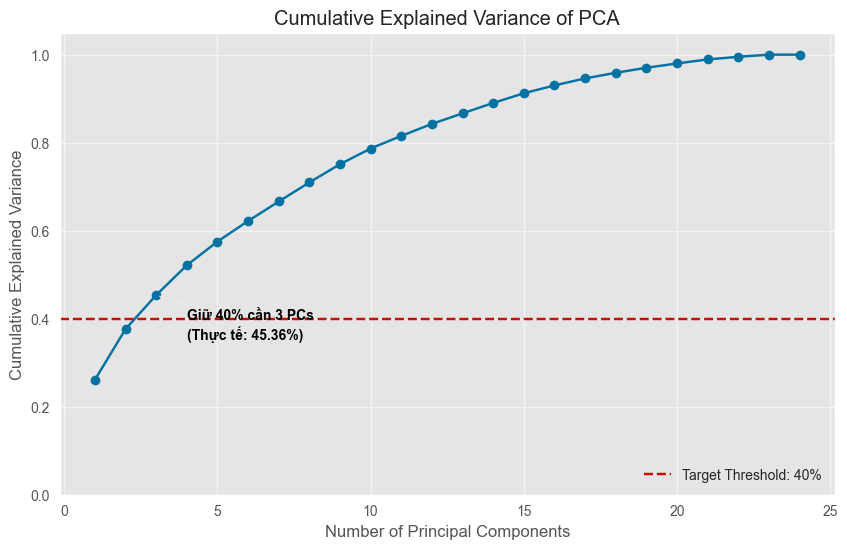

Để giữ ít nhất 40% dữ liệu, bạn nên dùng n_components = 3


In [83]:
# 1. Cấu hình ngưỡng mong muốn ở đây (0.7 = 70%, 0.9 = 90%)
target_variance = 0.40

plt.style.use('ggplot')

# 2. Chạy PCA
pca = PCA()
X_pca = pca.fit_transform(df_scaled)
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

# 3. Tự động tìm số lượng PC đạt ngưỡng đã chọn
n_components_target = np.argmax(cumulative_explained_variance >= target_variance) + 1
actual_variance = cumulative_explained_variance[n_components_target - 1]

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1),
         cumulative_explained_variance,
         marker='o', linestyle='-', color='b')

# Vẽ đường kẻ ngang tại ngưỡng đã chọn
plt.axhline(y=target_variance, color='r', linestyle='--',
            label=f'Target Threshold: {target_variance:.0%}')

# Chú thích điểm đạt ngưỡng
plt.annotate(f'Giữ {target_variance:.0%} cần {n_components_target} PCs\n(Thực tế: {actual_variance*100:.2f}%)',
             xy=(n_components_target, actual_variance),
             xytext=(n_components_target + 1, actual_variance - 0.1),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             color='black', weight='bold')

plt.title('Cumulative Explained Variance of PCA')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05) # Giới hạn trục y để dễ nhìn
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Để giữ ít nhất {target_variance:.0%} dữ liệu, bạn nên dùng n_components = {n_components_target}")


In [84]:
data_pca = PCA(n_components=3)
data_pca = data_pca.fit_transform(df_scaled)
data_pca

array([[ 2.78654495, -0.62693545,  0.44957119],
       [-2.20756736,  0.57261903, -0.40086114],
       [ 2.28405497, -0.82440795, -1.48422827],
       ...,
       [ 2.31337025, -1.38129532, -0.30804504],
       [ 1.51164933,  2.02691493, -0.99877502],
       [-1.4535209 ,  1.84606466,  1.57185831]], shape=(2216, 3))

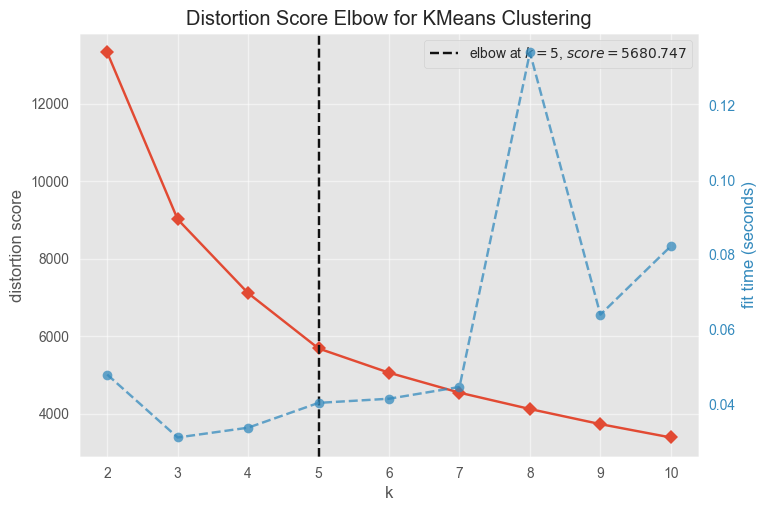

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [85]:
plt.style.use('ggplot')

elbow = KElbowVisualizer(KMeans(n_init = 10, random_state=42), k=10)
elbow.fit(data_pca)
elbow.show()

In [90]:
# Apply K-Means clustering
kmeans_3dim = KMeans(n_clusters=5, random_state=42, n_init= 10)
clusters_3dim = kmeans_3dim.fit_predict(data_pca)

In [91]:
df['Cluster'] = kmeans_3dim.labels_

/var/folders/p6/fth8lbts7y3b2m7w7_vqght40000gn/T/ipykernel_80673/903702836.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_cluster_count


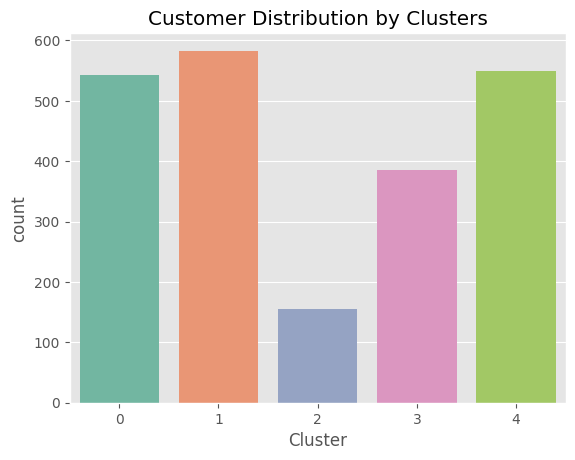

In [92]:
df_cluster_count = df.groupby(by = 'Cluster',as_index = False).agg(count = ('Cluster','count')).sort_values(by = 'Cluster',ascending=True)

plt.style.use('ggplot')

sns.barplot(data = df_cluster_count
            ,x = 'Cluster'
            ,y = 'count'
            ,palette='Set2')

plt.title('Customer Distribution by Clusters')
plt.show()

Text(0.5, 1.0, 'Relationship between Income & Total Spent of each Clusters')

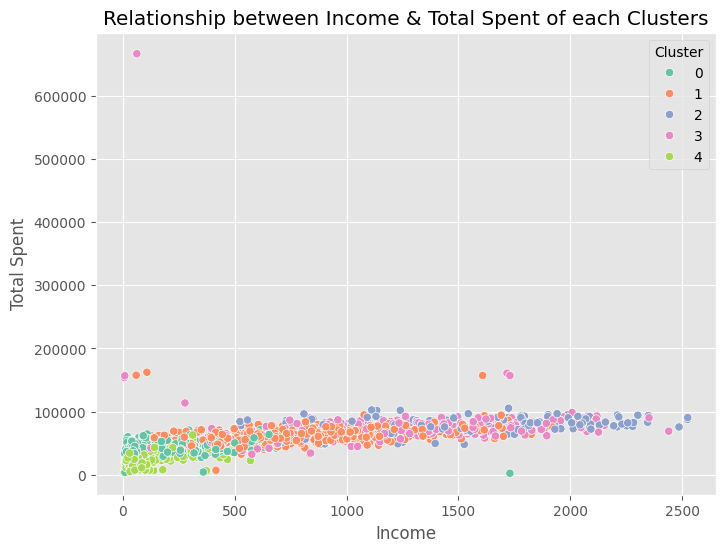

In [93]:
plt.figure(figsize = (8,6))

sns.scatterplot(data = df
                , y = 'Income'
                , x = 'Total_Spent'
                , hue = 'Cluster'
                , palette= 'Set2')

plt.xlabel('Income')
plt.ylabel('Total Spent')
plt.title('Relationship between Income & Total Spent of each Clusters')


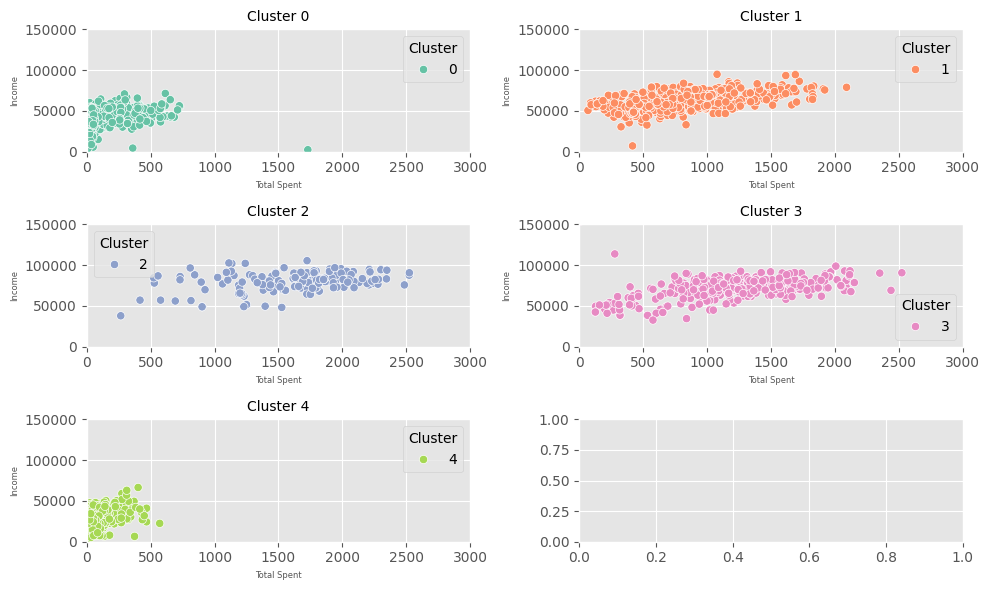

In [96]:
custom_palette = sns.color_palette("Set2", n_colors=len(df['Cluster'].unique()))

fig, axes = plt.subplots(3, 2, figsize=(10, 6))

for i, cluster in enumerate(sorted(df['Cluster'].unique())):
    row, col = divmod(i, 2)
    sns.scatterplot(data=df[df['Cluster'] == cluster], y='Income', x='Total_Spent', hue='Cluster', palette=[custom_palette[cluster]], ax=axes[row, col])
    axes[row, col].set_title(f'Cluster {cluster}',size = 10)
    axes[row, col].set_ylabel('Income',size = 6 )
    axes[row, col].set_xlabel('Total Spent', size = 6)
    axes[row, col].set_ylim(0, 150000)
    axes[row, col].set_xlim(0, 3000)

plt.tight_layout()
plt.show()

Demographics:

Cluster 0: Low Spent, Average Income.

Cluster 1: Average Spent, Average Income.

Cluster 2: High Spent, High Income (Best Targeted Customers).

Cluster 3: Average/High Spent, High Income (Potential Targeted Customers).

Cluster 4: Low Spent, Low Income.

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2216 non-null   object 
 1   Income               2216 non-null   float64
 2   Kidhome              2216 non-null   int64  
 3   Teenhome             2216 non-null   int64  
 4   Recency              2216 non-null   int64  
 5   NumDealsPurchases    2216 non-null   int64  
 6   NumWebPurchases      2216 non-null   int64  
 7   NumCatalogPurchases  2216 non-null   int64  
 8   NumStorePurchases    2216 non-null   int64  
 9   NumWebVisitsMonth    2216 non-null   int64  
 10  AcceptedCmp3         2216 non-null   int64  
 11  AcceptedCmp4         2216 non-null   int64  
 12  AcceptedCmp5         2216 non-null   int64  
 13  AcceptedCmp1         2216 non-null   int64  
 14  AcceptedCmp2         2216 non-null   int64  
 15  Complain             2216 non-null   int64 

In [98]:
# Chọn các cột số quan trọng để phân tích
analysis_cols = [
    'Age', 'Income', 'Total_Spent', 'Total_Children', 'Recency',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
    'Cluster'
]

# Tính trung bình theo từng Cluster
cluster_summary = df[analysis_cols].groupby('Cluster').mean().T

# Format số cho dễ nhìn
print("--- Chỉ số trung bình của từng Cluster ---")
display(cluster_summary.style.background_gradient(axis=1, cmap='RdYlGn'))

campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Cluster']

campaign_insight = df[campaign_cols].groupby('Cluster').mean() * 100 # Chuyển sang %

print("--- Tỷ lệ chấp nhận ưu đãi (%) theo Cluster ---")
display(campaign_insight.style.highlight_max(color='lightgreen', axis=0))



--- Chỉ số trung bình của từng Cluster ---


Cluster,0,1,2,3,4
Age,59.824723,61.780446,55.632258,58.691710,48.881818
Income,41751.214022,62607.593482,79707.774194,74635.437824,28157.345455
Total_Spent,170.415129,837.368782,1599.858065,1219.085492,83.969091
Total_Children,1.761993,1.137221,0.135484,0.015544,0.825455
Recency,48.625461,49.509434,42.077419,52.813472,48.154545
NumWebPurchases,2.988930,6.277873,5.658065,4.634715,2.012727
NumCatalogPurchases,0.878229,3.665523,6.232258,5.440415,0.436364
NumStorePurchases,3.765683,8.188679,7.987097,8.178756,2.990909
NumWebVisitsMonth,6.356089,5.152659,3.425806,2.603627,6.912727


--- Tỷ lệ chấp nhận ưu đãi (%) theo Cluster ---


,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
Cluster,,,,,,
0,0.369004,0.369004,6.826568,1.476015,0.000000,8.118081
1,2.915952,0.514580,5.145798,12.864494,1.715266,8.747856
2,60.000000,16.129032,23.870968,41.935484,72.903226,80.645161
3,7.772021,0.000000,2.590674,4.145078,10.103627,12.176166
4,0.000000,0.000000,8.909091,0.000000,0.000000,12.000000


In [99]:
# Tìm giá trị xuất hiện nhiều nhất của các cột object trong từng cluster
cat_cols = ['Education_Level', 'Living_Situation', 'Is_Parent', 'Cluster']

cat_insight = df[cat_cols].groupby('Cluster').agg(lambda x: x.value_counts().index[0])

print("--- Đặc điểm phổ biến nhất theo Cluster ---")
display(cat_insight)

--- Đặc điểm phổ biến nhất theo Cluster ---


,Education_Level,Living_Situation,Is_Parent
Cluster,,,
0,undergraduate,alone,1.0
1,undergraduate,alone,1.0
2,undergraduate,alone,0.0
3,undergraduate,alone,0.0
4,undergraduate,alone,1.0


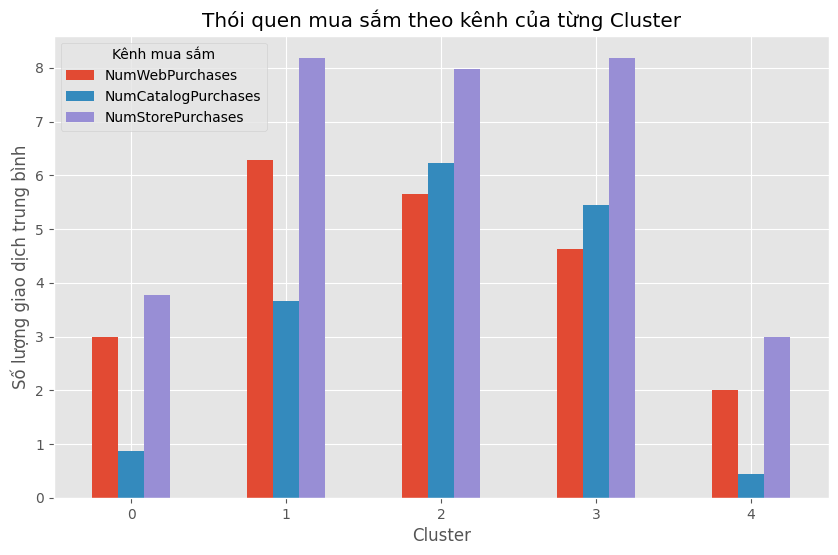

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

channels = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
channel_data = df.groupby('Cluster')[channels].mean()

channel_data.plot(kind='bar', figsize=(10, 6))
plt.title('Thói quen mua sắm theo kênh của từng Cluster')
plt.ylabel('Số lượng giao dịch trung bình')
plt.xticks(rotation=0)
plt.legend(title='Kênh mua sắm')
plt.show()

### 8. Conclusion

* Cluster 2: Khách hàng Tinh hoa (VIPs)

Nhân khẩu học: Thu nhập cao nhất (~80k), không có con cái (Is_Parent = 0).

Hành vi: Chi tiêu mạnh nhất (~1,600$), thích mua hàng qua Catalog và Cửa hàng.

**Insight: Đây là nhóm "con cưng" của doanh nghiệp. Tỷ lệ phản hồi chiến dịch cực cao (80.6% ở chiến dịch cuối).**

Chiến lược: Duy trì sự trung thành bằng các đặc quyền cao cấp và cá nhân hóa sâu.

* Cluster 3: Nhóm Thu nhập cao & Độc thân

Nhân khẩu học: Thu nhập cao (~74.6k), hầu như không có con cái.

Hành vi: Chi tiêu lớn (\~1,219$), kênh mua sắm chính là Cửa hàng. Ít lướt web nhất (~2.6 lượt/tháng).

**Insight: Những người bận rộn, có tiền nhưng ít nhạy cảm với các chiến dịch marketing đại trà.**

**Chiến lược: Tập trung vào chất lượng dịch vụ tại cửa hàng và các sản phẩm mang tính tiện lợi, đẳng cấp.**

* Cluster 1: Gia đình Trung lưu ổn định

Nhân khẩu học: Lớn tuổi nhất (\~62 tuổi), có con cái, thu nhập khá (\~62.6k).

Hành vi: Chi tiêu trung bình khá (\~837$), ưa chuộng mua sắm qua Web (\~6.3 giao dịch).

**Insight: Nhóm khách hàng ổn định, mua sắm có kế hoạch và thích sự tiện lợi của thương mại điện tử.**

**Chiến lược: Đẩy mạnh quảng cáo qua email/web và các sản phẩm dành cho gia đình.**

* Cluster 0: Gia đình Tiết kiệm (Budget Families)

Nhân khẩu học: Thu nhập trung bình thấp (~41.7k), có nhiều con nhất (trung bình 1.76 trẻ).

Hành vi: Chi tiêu thấp (~170$), ghé thăm web nhiều nhưng mua ít.

**Insight: Nhóm này rất nhạy cảm về giá và có gánh nặng tài chính từ con cái.

Chiến lược: Tập trung vào các chương trình giảm giá, mã khuyến mãi và "Flash Sale" trên web.**

* Cluster 4: Nhóm Trẻ & Thu nhập thấp

Nhân khẩu học: Trẻ tuổi nhất (\~48 tuổi), thu nhập thấp nhất (~28k).

Hành vi: Chi tiêu ít nhất (\~84$), ghé thăm web nhiều nhất nhưng tỷ lệ mua hàng Catalog/Store cực thấp.

**Insight: Khách hàng tiềm năng trong tương lai nhưng hiện tại chỉ đang "tham khảo" (window shopping).**

**Chiến lược: Giữ chân bằng các nội dung tương tác thú vị trên web, chưa nên đầu tư quá nhiều chi phí marketing trực tiếp.**